# Viscosity Interpolation

Some tests, examples of viscosity interpolation

As a rule, visoscity varies exponentially with temperature, so that's how we onterpolatie it

But something seemed wrong with some dat from LSFOs

Here's a check, using the KinematicViscosity Object from adios_db.computation

## Conclusion so far:

The fit to an exponential works well for crude oils -- which is what we determined way back when.

However -- it works really poorly for at least some ULSFOs -- maybe other distilled products as well.

## Solution?

First step is to check the residuals, and at least issue a warning.

Next step is to come up with a better interolatio method -- we could do piecwise (linear or exponential), but thatmight extrapolate really badly. That may not be SO bad for environmental conditions -- not a huge temp range --  but not great for labeling and the like.

I tried using only the outside two pooints -- not good.

Could a 3 parameter exponential fit work? IN theory, it should't -- viscosity should tend to zero at infinite temperature, but maybe it wold work OK locally -- at least it would exactly fit three points :-)

Hmm -- piecewise exponential, with the extrapolation using a the fit to the end points?




In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot  as plt
import matplotlib
import adios_db.scripting as ads
import adios_db.computation.physical_properties as pp
import csv
import scipy

In [2]:
# Here's an LSFO with dynamic viscosity data:
EXAMPLE_DATA_DIR = Path(r"C:\Users\rintaro.moriyasu\Oil Databases\noaa-oil-data\data\oil")

In [3]:
dir(ads)
ads.get_all_records
#pt = "Crude Oil NOS"
#pt = "Condensate"
#pt = "Bitumen Blend"
#pt = "Bitumen"
#pt = "Refined Product NOS"
#pt = "Distillate Fuel Oil"
#pt = "Residual Fuel Oil"
#pt = "Refinery Intermediate"
#pt = "Solvent"
#pt = "Bio-fuel Oil"
#pt = "Natural Plant Oil"
#pt = "Lube Oil"
#pt = "Dielectric Oil"
pt = "Other"
    
oil_visc = []
no_list = ['AD01706', 'EC00662', 'AD02290'] #these are orimulsions
for oil, filename in ads.get_all_records(EXAMPLE_DATA_DIR):
    product_type = oil.metadata.product_type
    if oil.oil_id in no_list:
        continue
    if product_type == pt:
        oil_visc.append(oil)


In [4]:
#sort through all records that have more than two Kinematic Viscosities
kv2_values = []
density_values = []
for oil in oil_visc:
#     if not oil.oil_id.startswith("AD"):
#         continue
    kv_data = oil.sub_samples[0].physical_properties.kinematic_viscosities
    errors = kv_data.validate()
    if errors:
        continue
    try:
        KV = pp.KinematicViscosity(oil)
    except ValueError:
        continue
    if len(KV.kviscs) > 1:
        k_v2 = KV._k_v2
        #if k_v2 < 28000:
        density = pp.Density(oil)
        d = density.at_temp(15, unit = 'C')
        if True:
            density_values.append(d)
            print(density_values[-1], oil.oil_id)
            kv2_values.append(k_v2)
#         else:
#             print("Removing", oil.oil_id)
#         if k_v2 > 24000:
#             print(oil.oil_id)
    

942.0 AD02009
820.0 AD02185


In [5]:
# mean_kv2 = np.average(kv2_values)
# print("Mean is", mean_kv2)
# stdev_kv2 = np.std(kv2_values)
# print("Standard Deviation is", stdev_kv2)
# median_kv2 = np.median(kv2_values)
# print("Median is", median_kv2)
# print("Max Value is", max(kv2_values))

Text(0, 0.5, 'Number of Oils')

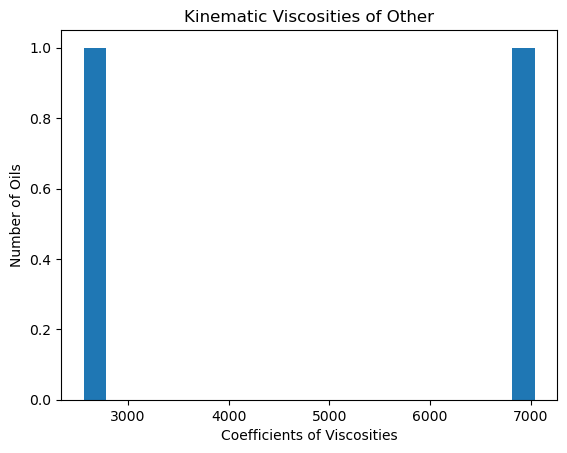

In [6]:
fig, ax = plt.subplots()
ax.hist(kv2_values, bins = 20)
ax.set_title("Kinematic Viscosities of " + pt)
plt.xlabel("Coefficients of Viscosities")
plt.ylabel("Number of Oils")


In [7]:
density_values = np.array(density_values)
res = scipy.stats.linregress(density_values, kv2_values, alternative='two-sided')
print(res)


LinregressResult(slope=36.73005910681198, intercept=-27557.176315490695, rvalue=1.0, pvalue=0.0, stderr=0.0, intercept_stderr=0.0)


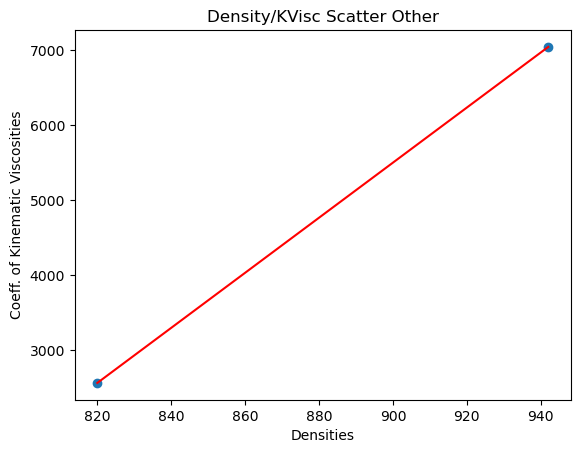

In [8]:
fig, ax = plt.subplots()
ax.scatter(density_values, kv2_values)
ax.set_title("Density/KVisc Scatter " + pt)
plt.xlabel("Densities")
plt.ylabel("Coeff. of Kinematic Viscosities")
plt.plot(density_values, res.intercept + res.slope*density_values, 'r', label='fitted line')

In [9]:
residuals = {}
no_list = ['AD00813', 'NO00119', 'NO00120','NO00121','NO00122', 'AD02582', 'AD01485' ]
matplotlib.rcParams['figure.max_open_warning'] = 240
for oil in oils[:]:
    validation = oil.validate()
    bad_oil = False
    for message in validation:
        if message.startswith("E062"):
            print("Skipping", oil.oil_id)
            bad_oil = True
            break
    if oil.oil_id in no_list:
        continue
    if bad_oil:
        continue
    
        
    oil_name = oil.metadata.name
    #print(oil_name)
    KV = pp.KinematicViscosity(oil)

    visc = KV.kviscs
    if len(visc) < 3:
        continue
    if KV.residuals[0] < 0.07:
        continue
    temps = KV.temps
    visc2 = KV.at_temp(temps)
    residuals[oil.oil_id] = KV.residuals[0]
    temps3 = np.linspace(min(temps), max(temps))
    visc3 = KV.at_temp(temps3)
    fig, ax = plt.subplots()
    ax.set_title(oil_name +" " + oil.oil_id)
    ax.plot(temps, visc, 'o')
    ax.plot(temps, visc2, 'x')
    ax.plot(temps3, visc3)
    ax.legend(["original points", "re-computed", "interpolator"])
    ax.text(min(temps3),min(visc3) , f"Residual: {KV.residuals}")


NameError: name 'oils' is not defined

In [ ]:
res = list(residuals.values())
fig, ax = plt.subplots()
ax.hist(res, bins = 20)
#     ax.set_title(oil_name +" " + oil.oil_id)
#     ax.plot(temps, visc, 'o')
#     ax.plot(temps, visc2, 'x')
#     ax.plot(temps3, visc3)
#     ax.legend(["original points", "re-computed", "interpolator"])
#     ax.text(min(temps3),min(visc3) , f"Residual: {KV.residuals}")

In [ ]:
max(res)
res_reversed = {res:id for id, res in residuals.items()}
res_reversed[max(res)]
res_reversed[min(res)]

In [ ]:
matplotlib.rcParams['figure.max_open_warning'] = 240